In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

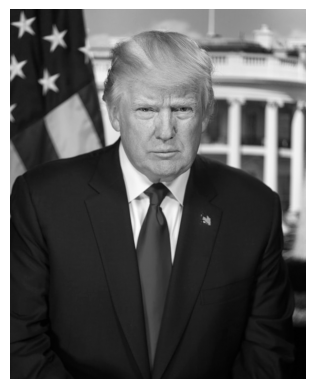

In [2]:

# Cargar la imagen en escala de grises (0 = grayscale)
img = cv2.imread("img_example.jpg", 0)

# Mostrar la imagen con matplotlib
plt.imshow(img, cmap='gray')
plt.axis('off')  # Ocultar los ejes
plt.show()

In [3]:
f_list = [3,3,2,1,0,0,0,1,3,1,3,1,2,2,3,2,0,0,2,2,2,0,0,0,1]
f=np.array(f_list).reshape(5,5)
f

array([[3, 3, 2, 1, 0],
       [0, 0, 1, 3, 1],
       [3, 1, 2, 2, 3],
       [2, 0, 0, 2, 2],
       [2, 0, 0, 0, 1]])

In [4]:
w_list=[0,1,2,2,2,0,0,1,2]
w=np.array(w_list).reshape(3,3)
w

array([[0, 1, 2],
       [2, 2, 0],
       [0, 1, 2]])

In [5]:

def convolucion(f,w):
    f_h,f_w = f.shape
    w_h,w_w = w.shape

    out_h = f_h-w_h+1
    out_w = f_w-w_w+1

    img_out = np.zeros((out_h,out_w))

    for i in range(out_h):
        for j in range(out_w):
            roi=f[i:i+w_h,j:j+w_w]
            img_out[i,j]=np.sum(roi*w) # Convolucion
            
    img_out = np.clip(img_out,0,255) # Clipping
    return img_out
        

print(convolucion(f,w)) # Imagen de salida

[[12. 12. 17.]
 [10. 17. 19.]
 [ 9.  6. 14.]]


In [6]:
# Filtros
# 1. Filtro de Enfoque (Sharpen)
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# 2. Filtro de Desenfoque (Blur / Caja)
kernel_blur = np.array([[1, 1, 1],
                        [1, 1, 1],
                        [1, 1, 1]]) / 9.0

# 3. Filtro Sobel Vertical (Detector de bordes verticales)
kernel_sobel_v = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

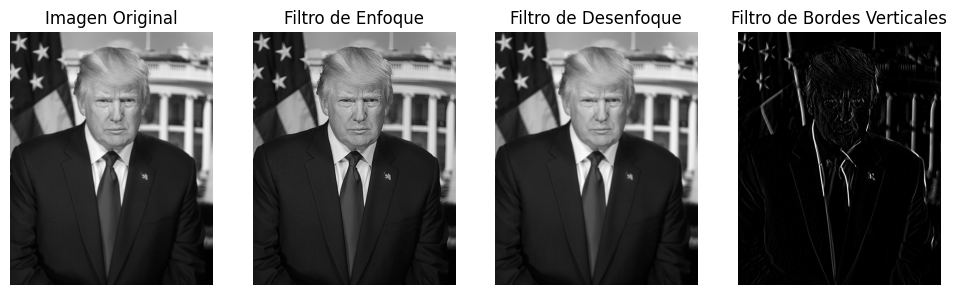

In [7]:
img_sharpen = convolucion(img,kernel_sharpen)
img_blur = convolucion(img,kernel_blur)
img_sobel_v = convolucion(img,kernel_sobel_v)

plt.figure(figsize=(12, 8))

# Mostrar la imagen original
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

# Mostrar el filtro de enfoque
plt.subplot(1, 4, 2)
plt.imshow(img_sharpen, cmap='gray')
plt.title('Filtro de Enfoque')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_blur, cmap='gray')
plt.title('Filtro de Desenfoque')
plt.axis('off')

# Mostrar el filtro de bordes verticales
plt.subplot(1, 4, 4)
plt.imshow(img_sobel_v, cmap='gray')
plt.title('Filtro de Bordes Verticales')
plt.axis('off')

plt.show()

